# German Macro Regime Dashboard
**Author:** Shardul Pundir | Economics Graduate, MS Finance (WHU 2026)

This notebook combines IFO, ZEW, ECB, and DAX data to classify the current German macroeconomic regime into one of four phases: **Expansion / Slowdown / Contraction / Recovery**.

In [12]:
import os, sys
import warnings
warnings.filterwarnings('ignore')

# --- PATH SETUP: point to the src/ folder ---
SRC_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# --- FRED API KEY (needed for IFO data from FRED) ---
FRED_API_KEY = 'b61fbad6251fb1d531015344cd52605e'

# --- START DATE for historical charts ---
START_DATE = '2019-01-01'

print('src path:', SRC_DIR)
print('Python path OK:', os.path.exists(SRC_DIR))


src path: C:\Users\shardul.pundir\Claude_Anthropic\Finance Project\german-macro-dashboard\src
Python path OK: True


In [13]:
from ifo_data import fetch_ifo_from_fred, compute_ifo_signals, get_ifo_regime_score

print("Fetching IFO Business Climate from FRED...")
ifo_df = fetch_ifo_from_fred(FRED_API_KEY, start_date=START_DATE)
ifo_df = compute_ifo_signals(ifo_df)
ifo_score = get_ifo_regime_score(ifo_df)

print(f"  IFO Climate: {ifo_score['ifo_climate']}")
print(f"  Expectations Gap: {ifo_score['expectations_gap']:+.1f}")
print(f"  Direction: {ifo_score['climate_direction']}")
print(f"  IFO Regime Score: {ifo_score['ifo_score']}/25")
print(f"  As of: {ifo_score['as_of']}")


Fetching IFO Business Climate from FRED...
  ✓ FRED: ifo_climate (61 obs)
  IFO Climate: 98.95
  Expectations Gap: +1.5
  Direction: flat
  IFO Regime Score: 11/25
  As of: 2024-01-01


In [14]:
from zew_data import fetch_zew_from_fred, compute_zew_signals, get_zew_regime_score

print("Fetching ZEW Sentiment (live PDF + historical)...")
zew_df = fetch_zew_from_fred(FRED_API_KEY, start_date=START_DATE)
zew_df = compute_zew_signals(zew_df)
zew_score = get_zew_regime_score(zew_df)

print(f"  ZEW Expectations: {zew_score['zew_expectations']:+.1f}")
print(f"  Trend: {zew_score['zew_trend']}")
print(f"  Divergence (Exp - Current): {zew_score['zew_divergence']:+.1f}")
print(f"  ZEW Regime Score: {zew_score['zew_score']}/25")
print(f"  As of: {zew_score['as_of']}")


Fetching ZEW Sentiment (live PDF + historical)...
  Fetching ZEW live data from ZEW PDF...
  ZEW survey period: March 2026
  ZEW Indicator (Expectations): -0.5
  ZEW Current Conditions:       -62.9
  ZEW: 87 months loaded (historical + live PDF).
  ZEW Expectations: -0.5
  Trend: deteriorating
  Divergence (Exp - Current): +62.4
  ZEW Regime Score: 6/25
  As of: 2026-03-01


In [15]:
from ecb_macro import get_monthly_macro
from regime_classifier import get_ecb_regime_score

print("Fetching ECB macro data (Bund yields, deposit rate, HICP)...")
try:
    ecb_df = get_monthly_macro(start_date=START_DATE)
    ecb_score = get_ecb_regime_score(ecb_df)
    print(f"  ECB Deposit Rate: {ecb_score.get('ecb_rate', 'N/A')}%")
    print(f"  2s10s Spread: {ecb_score.get('curve_spread', 'N/A')}%")
    print(f"  EA HICP: {ecb_score.get('hicp_ea', 'N/A')}%")
    print(f"  ECB Regime Score: {ecb_score['ecb_score']}/25")
except Exception as e:
    print(f"  ECB fetch failed: {e}")
    ecb_df = None
    ecb_score = {'ecb_score': 12, 'note': 'Fallback neutral score'}
    print("  Using neutral ECB score (12/25)")


Fetching ECB macro data (Bund yields, deposit rate, HICP)...
  ✓ ecb_deposit_rate: 19 obs
  ✓ bund_2y: 1860 obs
  ✓ bund_5y: 1860 obs
  ✓ bund_10y: 1860 obs
  ✓ hicp_ea: 84 obs
  ✓ hicp_de: 84 obs
  ECB Deposit Rate: nan%
  2s10s Spread: 0.586%
  EA HICP: None%
  ECB Regime Score: 16/25


In [18]:
from dax_data import fetch_returns, get_sector_regime_alignment
from regime_classifier import get_equity_regime_score

print("Fetching DAX sector data from Yahoo Finance...")
try:
    dax_df = fetch_returns(start_date='2024-01-01')
    sector_signal = get_sector_regime_alignment(dax_df)
    equity_score = get_equity_regime_score(sector_signal)
    print(f"  Cyclical vs Defensive spread: {equity_score.get('cyclical_spread', 'N/A'):+.1f}%")
    print(f"  Market signal: {sector_signal.get('market_regime_signal', 'N/A')}")
    print(f"  Equity Regime Score: {equity_score['equity_score']}/25")
except Exception as e:
    print(f"  DAX fetch failed: {e}")
    sector_signal = {}
    equity_score = {'equity_score': 12, 'note': 'Fallback neutral score'}
    print("  Using neutral equity score (12/25)")


Fetching DAX sector data from Yahoo Finance...
  Cyclical vs Defensive spread: +9.4%
  Market signal: Cyclical outperformance → market pricing Expansion
  Equity Regime Score: 25/25


In [19]:
from regime_classifier import classify_regime, print_regime_summary

regime_result = classify_regime(ifo_score, zew_score, ecb_score, equity_score)
print_regime_summary(regime_result)



  GERMAN MACRO REGIME DASHBOARD
  As of: 2026-04-18

  REGIME:     SLOWDOWN  [58/100]
  Confidence: Moderate

  Growth decelerating. IFO declining, ZEW softening. PMI approaching 50. Defensive rotation beginning. ECB may be at or near peak rates.

  Component Scores:
    IFO     : 11/25  ████████░░░░░░░░░░░░
    ZEW     :  6/25  ████░░░░░░░░░░░░░░░░
    ECB     : 16/25  ████████████░░░░░░░░
    EQUITY  : 25/25  ████████████████████

  Sector Playbook:
    Overweight : Healthcare, Consumer Staples, Technology (quality)
    Underweight: Autos, Banks, Materials
    Bonds      : Duration neutral — beginning to add as rates peak




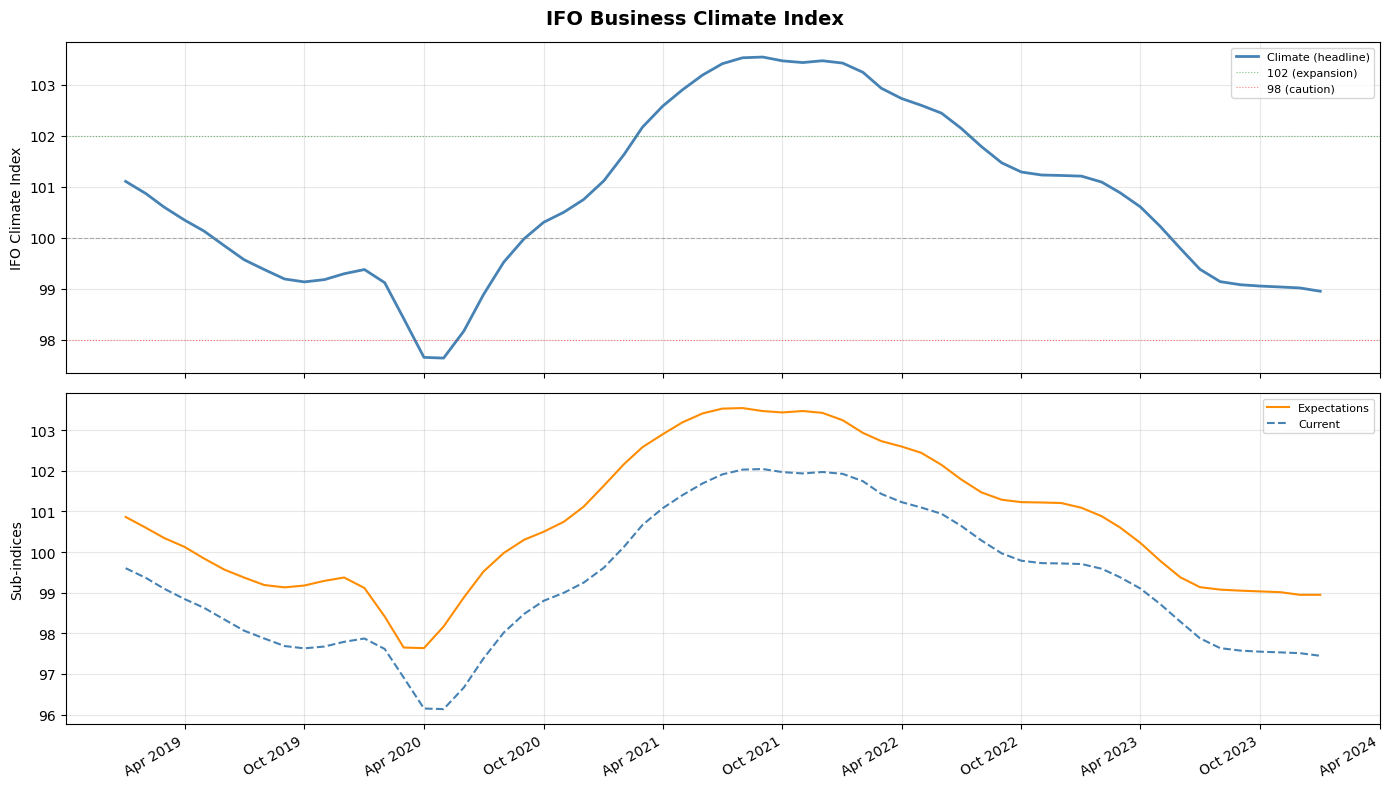

IFO chart saved.


In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('IFO Business Climate Index', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.plot(ifo_df.index, ifo_df['ifo_climate'], color='steelblue', lw=2, label='Climate (headline)')
ax1.axhline(100, color='grey', lw=0.8, linestyle='--', alpha=0.6)
ax1.axhline(102, color='green', lw=0.8, linestyle=':', alpha=0.5, label='102 (expansion)')
ax1.axhline(98, color='red', lw=0.8, linestyle=':', alpha=0.5, label='98 (caution)')
ax1.set_ylabel('IFO Climate Index')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(ifo_df.index, ifo_df['ifo_expectations'], color='darkorange', lw=1.5, label='Expectations')
ax2.plot(ifo_df.index, ifo_df['ifo_current'], color='steelblue', lw=1.5, linestyle='--', label='Current')
ax2.set_ylabel('Sub-indices')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../outputs/ifo_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print("IFO chart saved.")


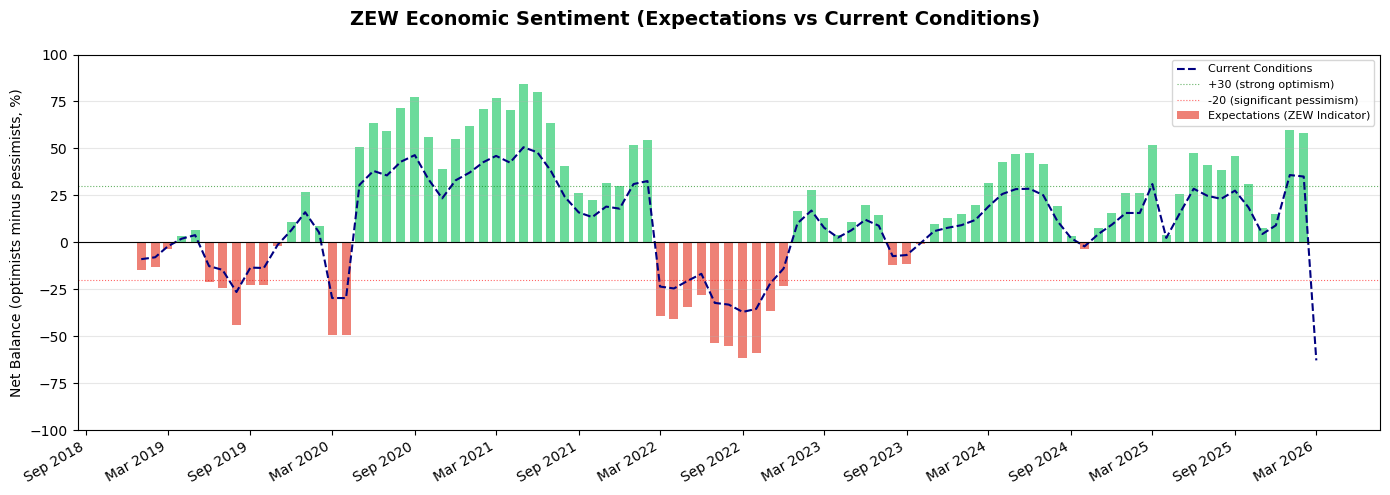

ZEW chart saved.


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('ZEW Economic Sentiment (Expectations vs Current Conditions)', fontsize=14, fontweight='bold')

# Bar chart with colour coding
values_exp = zew_df['zew_expectations'].values
dates = zew_df.index
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in values_exp]

ax.bar(dates, values_exp, color=colors, alpha=0.7, width=20, label='Expectations (ZEW Indicator)')
ax.plot(dates, zew_df['zew_current'], color='navy', lw=1.5, linestyle='--', label='Current Conditions')
ax.axhline(0,  color='black', lw=0.8)
ax.axhline(30, color='green', lw=0.8, linestyle=':', alpha=0.6, label='+30 (strong optimism)')
ax.axhline(-20, color='red', lw=0.8, linestyle=':', alpha=0.6, label='-20 (significant pessimism)')
ax.set_ylabel('Net Balance (optimists minus pessimists, %)')
ax.set_ylim(-100, 100)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../outputs/zew_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print("ZEW chart saved.")


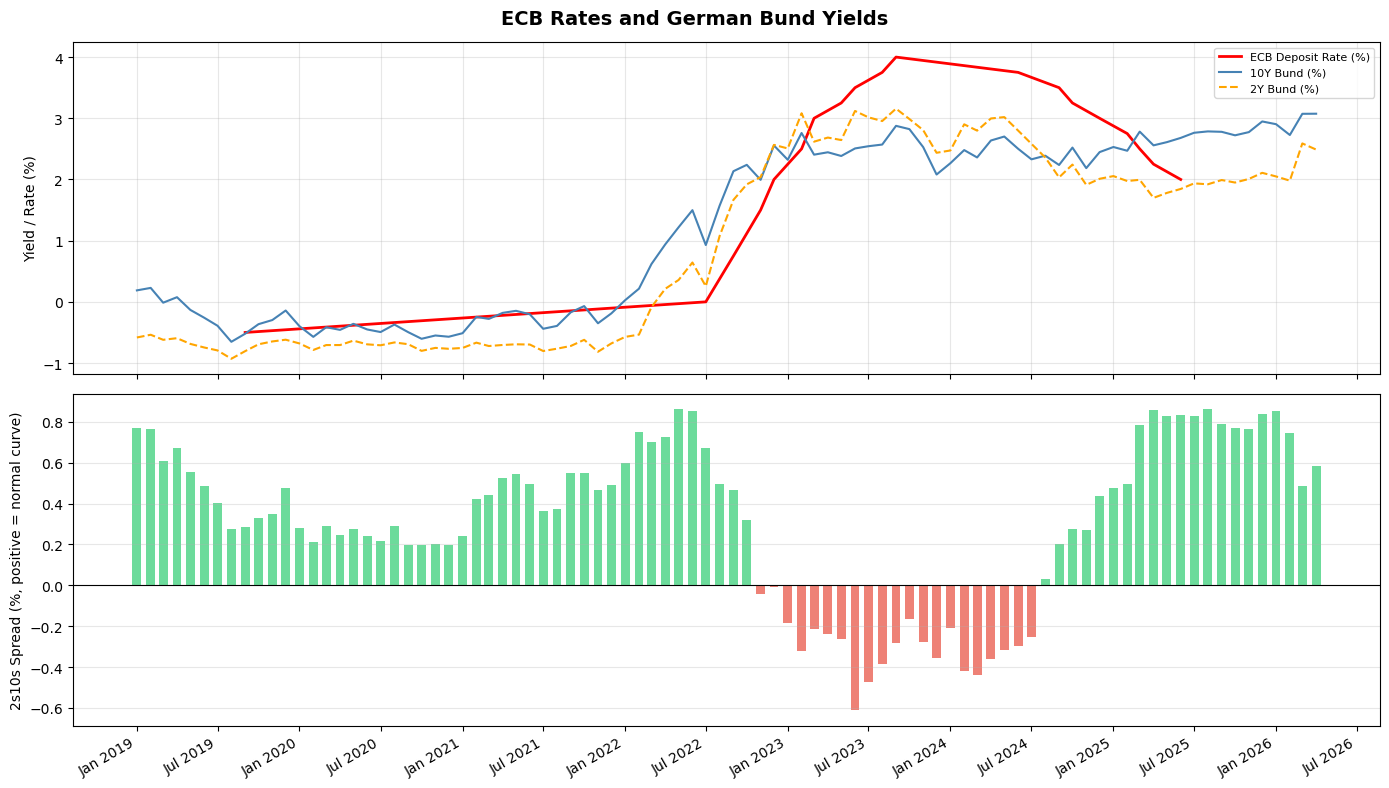

ECB chart saved.


In [22]:
if ecb_df is not None and not ecb_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle('ECB Rates and German Bund Yields', fontsize=14, fontweight='bold')

    ax1 = axes[0]
    if 'ecb_deposit_rate' in ecb_df.columns:
        ecb_monthly = ecb_df['ecb_deposit_rate'].resample('MS').last().dropna()
        ax1.plot(ecb_monthly.index, ecb_monthly.values, color='red', lw=2, label='ECB Deposit Rate (%)')
    if 'bund_10y' in ecb_df.columns:
        bund_monthly = ecb_df['bund_10y'].resample('MS').last().dropna()
        ax1.plot(bund_monthly.index, bund_monthly.values, color='steelblue', lw=1.5, label='10Y Bund (%)')
    if 'bund_2y' in ecb_df.columns:
        bund_2y = ecb_df['bund_2y'].resample('MS').last().dropna()
        ax1.plot(bund_2y.index, bund_2y.values, color='orange', lw=1.5, linestyle='--', label='2Y Bund (%)')
    ax1.set_ylabel('Yield / Rate (%)')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    if 'bund_10y' in ecb_df.columns and 'bund_2y' in ecb_df.columns:
        bund_10y_m = ecb_df['bund_10y'].resample('MS').last()
        bund_2y_m = ecb_df['bund_2y'].resample('MS').last()
        spread = (bund_10y_m - bund_2y_m).dropna()
        spread_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in spread.values]
        ax2.bar(spread.index, spread.values, color=spread_colors, alpha=0.7, width=20)
        ax2.axhline(0, color='black', lw=0.8)
        ax2.set_ylabel('2s10s Spread (%, positive = normal curve)')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        plt.xticks(rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig('../outputs/ecb_chart.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("ECB chart saved.")
else:
    print("ECB data unavailable -- skipping chart.")


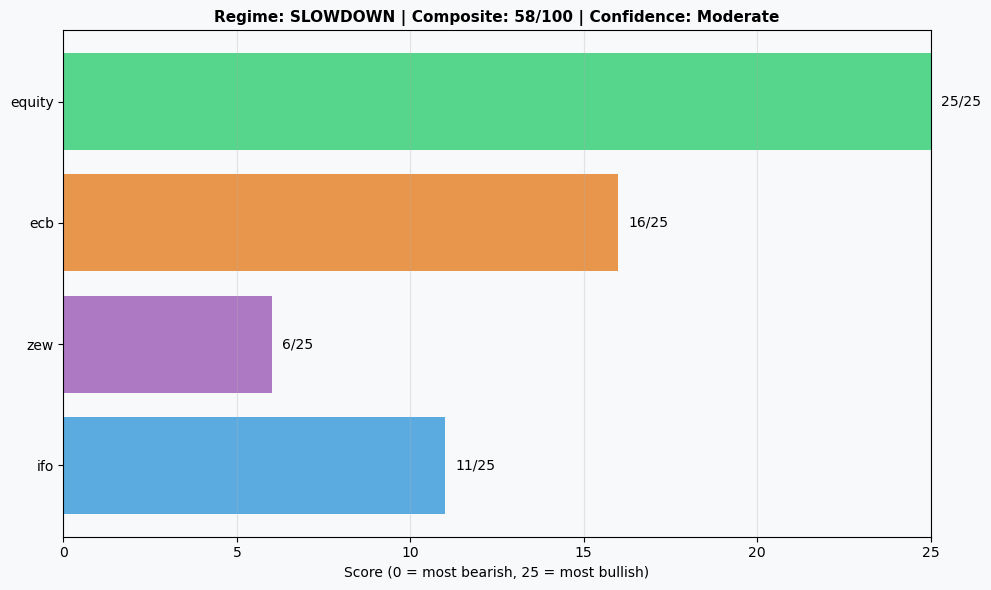

Regime gauge saved.


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

scores = regime_result['component_scores']
components = list(scores.keys())
values = list(scores.values())
colors_map = {'ifo': '#3498db', 'zew': '#9b59b6', 'ecb': '#e67e22', 'equity': '#2ecc71'}
bar_colors = [colors_map.get(c, 'grey') for c in components]

bars = ax.barh(components, values, color=bar_colors, alpha=0.8)
ax.axvline(25, color='grey', lw=0.8, linestyle='--', alpha=0.5)
ax.set_xlim(0, 25)
ax.set_xlabel('Score (0 = most bearish, 25 = most bullish)')
ax.set_title(
    f"Regime: {regime_result['regime'].upper()} | "
    f"Composite: {regime_result['composite_score']}/100 | "
    f"Confidence: {regime_result['regime_confidence']}",
    fontsize=11, fontweight='bold'
)
for bar, val in zip(bars, values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val}/25',
            va='center', fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/regime_gauge.png', dpi=120, bbox_inches='tight')
plt.show()
print("Regime gauge saved.")


In [24]:
from datetime import date

ecb_rate_str = str(ecb_score.get('ecb_rate', 'N/A'))
hicp_ea_str = str(ecb_score.get('hicp_ea', 'N/A'))
spread_str = str(ecb_score.get('curve_spread', 'N/A'))

commentary = f'''GERMAN MACRO REGIME DASHBOARD
Generated: {date.today().strftime('%d %B %Y')}
==============================

REGIME: {regime_result['regime'].upper()}
Composite Score: {regime_result['composite_score']}/100
Confidence: {regime_result['regime_confidence']}

SUMMARY:
{regime_result['regime_description']}

COMPONENT SCORES:
  IFO (Business Climate): {scores['ifo']}/25
  ZEW (Financial Sentiment): {scores['zew']}/25
  ECB (Rates/Inflation): {scores['ecb']}/25
  Equity (Sector Rotation): {scores['equity']}/25

KEY DATA POINTS:
  IFO Climate Index:    {ifo_score['ifo_climate']}
  ZEW Expectations:     {zew_score['zew_expectations']:+.1f} ({zew_score['zew_trend']})
  ECB Deposit Rate:     {ecb_rate_str}%
  EA HICP Inflation:    {hicp_ea_str}%
  Bund 2s10s Spread:    {spread_str}%

SECTOR PLAYBOOK:
  Overweight:  {', '.join(regime_result['sector_playbook']['overweight'])}
  Underweight: {', '.join(regime_result['sector_playbook']['underweight'])}
  Bonds:       {regime_result['sector_playbook']['bond_view']}
'''

print(commentary)
os.makedirs('../outputs', exist_ok=True)
fname = '../outputs/weekly_commentary.txt'
with open(fname, 'w', encoding='utf-8') as f:
    f.write(commentary)
print(f"Commentary saved to {fname}")


GERMAN MACRO REGIME DASHBOARD
Generated: 18 April 2026

REGIME: SLOWDOWN
Composite Score: 58/100
Confidence: Moderate

SUMMARY:
Growth decelerating. IFO declining, ZEW softening. PMI approaching 50. Defensive rotation beginning. ECB may be at or near peak rates.

COMPONENT SCORES:
  IFO (Business Climate): 11/25
  ZEW (Financial Sentiment): 6/25
  ECB (Rates/Inflation): 16/25
  Equity (Sector Rotation): 25/25

KEY DATA POINTS:
  IFO Climate Index:    98.95
  ZEW Expectations:     -0.5 (deteriorating)
  ECB Deposit Rate:     nan%
  EA HICP Inflation:    None%
  Bund 2s10s Spread:    0.586%

SECTOR PLAYBOOK:
  Overweight:  Healthcare, Consumer Staples, Technology (quality)
  Underweight: Autos, Banks, Materials
  Bonds:       Duration neutral — beginning to add as rates peak

Commentary saved to ../outputs/weekly_commentary.txt
